---
title: Gaussian Multivariate Bayesian State Inference
subtitle: Using RxInfer to estimate the hidden state vector
author: Kobus Esterhuysen
date: '2024-10-11'
date-modified: last-modified
categories:
  - Aerospace Industry
  - Bayesian Inference
  - Active Inference
  - RxInfer
  - Julia
image: GaussianMvStateInference.png
format:
  html:
    toc: true
    toc-depth: 4
    toc-expand: true
    toc-title: TOC
    code-fold: false
---

In [ ]:
#| hide
# BASED ON
  # GaussianMvStateInference_BLOG^v3.ipynb
  # GaussianMvStateInference_BLOG^v1.ipynb
  # Kalman filtering and smoothing-1_ANNO^V5.ipynb
  # Kalman filtering and smoothing_ANNO^V4.ipynb
  # Kalman filtering and smoothing_ANNO^V3.ipynb
  # Kalman filtering and smoothing_ANNO^V2.ipynb
  # Kalman filtering and smoothing_ANNO^V1.ipynb
  # GP regression by SSM.ipynb

# DONE
# v1 starts ------------------------------------------------
# migrated to RxInfer 3.0.0
# brought over my changes from RxInfer v2.16.2
# Use \mathbf for structures
# x_tL1 & w_tL1 with nice subscripts
# v2 starts ------------------------------------------------
# \mathcal{P} & \mathcal{Q} --> \mathbf{P} & \mathbf{Q}
# insert f() & g() functions
  # works with generating data; took out again to rather have same in both places
  # does NOT work inside @model (same as https://learnableloop.ai/posts/WeightVsHeight_BLOG.html)
    # seems to take literal symbols in the code to build FFG, so
      # x[t] ~ MvNormalMeanCovariance(f(A= A, xₜ₋₁= xₜ₋₁) does not work
# generate_data() --> sim_point_data
# for 'system identification' section: x --> v
  # the 'x' here is not associated with state but just a name for one of the signals
  # 'v' will go better with the other signal called 'w'
# s (for sum, in 'system identification' section) --> z
  # need s for state (which still need to be changed)
# v3 starts ------------------------------------------------
# change x --> s (for state)
# add tildes to hidden state
# v4 starts ------------------------------------------------
# switch roles of A & B
# change P matrix to R matrix
# clean up missing data section
# standardize symbols to DeVries
# have fp() & fr() in envir, but not in agent
  # maybe in future can remove fp() & fr() from envir too
      # so that they look more similar
      # however, I need to have fp() & fr() implemented somewhere 
# v5 starts ------------------------------------------------
# clean
# v1 starts ------------------------------------------------
# change to 3D rotation
# update narrative
# v2 starts ------------------------------------------------
# clean to publish
# v4 starts ------------------------------------------------
# change s --> x (for state)
# tildes --> * for true quantities 
  # (keep breves for now, not sure why they were done like this)
# switch roles of A & B back again to eng convention, but B --> C
# remove all underscores indicating globals
# add underscores for bold symbols which have spatial structure
# clean for publication

# TODO
# insert (modified) CRISP-DM structure
# replace code vars with math symbols
  # makes mapping between literature and code better to enhance understanding
  # make expressions more concise due to reduced wordyness
# replace hardcoded parameters with symbols


Multivariate Bayesian State estimation is performed using the `RxInfer` Julia package. The hidden states are a vector of three Gaussians.

In [1]:
versioninfo() ## Julia version

Julia Version 1.10.5
Commit 6f3fdf7b362 (2024-08-27 14:19 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 12 × Intel(R) Core(TM) i7-8700B CPU @ 3.20GHz
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, skylake)
Threads: 1 default, 0 interactive, 1 GC (on 12 virtual cores)


In [2]:
import Pkg
Pkg.add(Pkg.PackageSpec(;name="RxInfer"))
Pkg.add("Plots")
Pkg.add("StableRNGs")
Pkg.add("LaTeXStrings")
Pkg.add("Distributions")

using RxInfer, Random, Plots, StableRNGs, LaTeXStrings, Distributions

   Resolving package versions...
  No Changes to `/workspaces/GaussianMvStateInference/Project.toml`
  No Changes to `/workspaces/GaussianMvStateInference/Manifest.toml`
   Resolving package versions...
  No Changes to `/workspaces/GaussianMvStateInference/Project.toml`
  No Changes to `/workspaces/GaussianMvStateInference/Manifest.toml`
   Resolving package versions...
  No Changes to `/workspaces/GaussianMvStateInference/Project.toml`
  No Changes to `/workspaces/GaussianMvStateInference/Manifest.toml`
   Resolving package versions...
  No Changes to `/workspaces/GaussianMvStateInference/Project.toml`
  No Changes to `/workspaces/GaussianMvStateInference/Manifest.toml`
   Resolving package versions...
  No Changes to `/workspaces/GaussianMvStateInference/Project.toml`
  No Changes to `/workspaces/GaussianMvStateInference/Manifest.toml`


In [3]:
Pkg.status()

Status `/workspaces/GaussianMvStateInference/Project.toml`
  [6e4b80f9] BenchmarkTools v1.8.0
  [31c24e10] Distributions v0.25.131
  [b964fa9f] LaTeXStrings v1.4.1
⌃ [91a5bcdd] Plots v1.41.6
⌃ [86711068] RxInfer v3.7.1
  [860ef19b] StableRNGs v1.0.4
Info Packages marked with ⌃ have new versions available and may be upgradable.


## Multivariate Linear Gaussian State Space Model

A multivariate Multivariate Linear Gaussian State Space Model (LGSSM) can be described with the equations:

$$\begin{aligned}
 p(\mathbf{x}_t|\mathbf{x}_{t - 1}) & = \mathcal{N}(\mathbf{x}_t|\mathbf{\breve{A}} \mathbf{x}_{t - 1}, \mathbf{Q}),\\
 p(\mathbf{y}_t|\mathbf{x}_t) & = \mathcal{N}(\mathbf{y}_t|\mathbf{\breve{C}} \mathbf{x}_t, \mathbf{R}),
\end{aligned}$$

where $\mathbf{x}_t$ are hidden states, $\mathbf{y}_t$ are noisy observations, $\mathbf{\breve{A}}$, $\mathbf{\breve{C}}$ are state transition and observation matrices, $\mathbf{Q}$ and $\mathbf{R}$ are state transition noise and observation noise covariance matrices.

To make things more interesting, we will use a state space model that is subject to rotation in 3 dimensions, i.e. along the x, y, and z axes. This is a common use case for flying aircraft that rotate relative to a ground-based frame of coordinates. Once we have the transition and observation matrices for rotation around all 3 axes, we will use these matrices for the final state space model. Eventually, we will perform bayesian multivariate inference of the random vector $\mathbf{x}_t$. Note that this state space model does not capture the complete dynamics of a rotating object - only the location is included. 

1. **State Space Model without Rotation (3D)**

$$
\mathbf{x}_t = \mathbf{\breve{A}} \mathbf{x}_{t-1}
$$
$$
\mathbf{y}_t = \mathbf{\breve{C}} \mathbf{x}_t
$$

where:
$$
\mathbf{x}_t = \begin{bmatrix} x_{1t} \\ x_{2t} \\ x_{3t} \end{bmatrix} = \begin{bmatrix} x_{t} \\ y_{t} \\ z_{t} \end{bmatrix}
$$
and $x, y, z$ is the location coordinates in 3D space.

$$
\mathbf{y}_t = \begin{bmatrix} y_{1t} \\ y_{2t} \\ y_{3t} \end{bmatrix}
$$

2. **Rotation Matrices for Each Axis**

- Rotation around the x-axis by $\alpha$:

$$
\mathbf{\Phi}_x(\alpha) = \begin{bmatrix}
1 & 0 & 0 \\
0 & \cos(\alpha) & -\sin(\alpha) \\
0 & \sin(\alpha) & \cos(\alpha)
\end{bmatrix}
$$

- Rotation around the y-axis by $\beta$:

$$
\mathbf{\Phi}_y(\beta) = \begin{bmatrix}
\cos(\beta) & 0 & \sin(\beta) \\
0 & 1 & 0 \\
-\sin(\beta) & 0 & \cos(\beta)
\end{bmatrix}
$$

- Rotation around the z-axis by $\gamma$:

$$
\mathbf{\Phi}_z(\gamma) = \begin{bmatrix}
\cos(\gamma) & -\sin(\gamma) & 0 \\
\sin(\gamma) & \cos(\gamma) & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

3. **Combined Rotation Matrix in 3D**

$$
\mathbf{\Phi}(\alpha, \beta, \gamma) = \mathbf{\Phi}_z(\gamma) \mathbf{\Phi}_y(\beta) \mathbf{\Phi}_x(\alpha)
$$

$$
\mathbf{\Phi}(\alpha, \beta, \gamma) = \begin{bmatrix}
\cos(\gamma)\cos(\beta) & \cos(\gamma)\sin(\beta)\sin(\alpha) - \sin(\gamma)\cos(\alpha) & \cos(\gamma)\sin(\beta)\cos(\alpha) + \sin(\gamma)\sin(\alpha) \\
\sin(\gamma)\cos(\beta) & \sin(\gamma)\sin(\beta)\sin(\alpha) + \cos(\gamma)\cos(\alpha) & \sin(\gamma)\sin(\beta)\cos(\alpha) - \cos(\gamma)\sin(\alpha) \\
-\sin(\beta) & \cos(\beta)\sin(\alpha) & \cos(\beta)\cos(\alpha)
\end{bmatrix}
$$

4. **State Space Model with Rotation (3D)**

$$
\mathbf{x}_t = \mathbf{\breve{A}} \mathbf{\Phi}(\alpha, \beta, \gamma) \mathbf{x}_{t-1} = \mathbf{\Phi}(\alpha, \beta, \gamma) \mathbf{x}_{t-1} = \mathbf{A} \mathbf{x}_{t-1}
$$
(when $\mathbf{\breve{A}}$ is set to the identity matrix)

and the output equation:

$$
\mathbf{y}_t = \mathbf{\breve{C}} \mathbf{\Phi}(\alpha, \beta, \gamma) \mathbf{s}_t = \mathbf{\Phi}(\alpha, \beta, \gamma) \mathbf{x}_t = \mathbf{C} \mathbf{x}_t
$$
(when $\mathbf{\breve{C}}$ is set to the identity matrix).

In [3]:
seed = 777
rng = MersenneTwister(seed)
_xˣ₀ = [ 1.0, 2.0, 3.0 ]
αˣ = 0.025 ## radians
βˣ = 0.03 ## radians
γˣ = 0.02 ## radians
_Φˣ_x = [1        0         0;
         0        cos(αˣ)  -sin(αˣ);
         0        sin(αˣ)  cos(αˣ)]
_Φˣ_y = [cos(βˣ)  0        sin(βˣ);
         0         1        0;
         -sin(βˣ) 0        cos(βˣ)]
_Φˣ_z = [cos(γˣ)  -sin(γˣ) 0;
         sin(γˣ)  cos(γˣ)  0;
         0        0        1]
_Φˣ = _Φˣ_x * _Φˣ_y * _Φˣ_z
_Aˣ = [1 0 0;
       0 1 0;
       0 0 1]*_Φˣ
_Cˣ = [1 0 0;
       0 1 0;
       0 0 1]*_Φˣ
_Qˣ = diageye(3)
_Rˣ = 20.0 .* diageye(3)
T = 200; ## number of observations

In [4]:
_Φˣ

3×3 Matrix{Float64}:
  0.99935    -0.0199897   0.0299955
  0.0207421   0.999473   -0.0249861
 -0.0294802   0.0255921   0.999238

In [5]:
_Aˣ

3×3 Matrix{Float64}:
  0.99935    -0.0199897   0.0299955
  0.0207421   0.999473   -0.0249861
 -0.0294802   0.0255921   0.999238

In [6]:
_Cˣ

3×3 Matrix{Float64}:
  0.99935    -0.0199897   0.0299955
  0.0207421   0.999473   -0.0249861
 -0.0294802   0.0255921   0.999238

In [7]:
_Qˣ

3×3 Matrix{Float64}:
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0

In [8]:
_Rˣ

3×3 Matrix{Float64}:
 20.0   0.0   0.0
  0.0  20.0   0.0
  0.0   0.0  20.0

## The Generative Process

Next, we will generate some synthetic data.

### Provision function ($f_p$)
The *provision* function, provides another *covariate vector*. Because this is a *sequential* system, the provision function defines the transition between the previous state and the current state. This special case of the provision function is known as a *transition* function and it returns a *provision/pre-state*:

$$\mathbf{p^*}_{t} = f_p(\mathbf{x^*}_{t-1}) = f_A(\mathbf{x^*}_{t-1}) = \mathbf{A^*} \mathbf{x^*}_{t-1}$$

When we add *system noise* the next *state* is produced:

$$\mathbf{x^*}_{t} = \mathcal{N}(\mathbf{p^*}_{t}, \mathbf{Q^*})$$

The `asterisks, *` indicate that the parameters and variables are true and not observed.

In [9]:
## provision function, provides another covariate vector
function fₚ(; _Aˣ, _xˣₜ₋₁)
    return _Aˣ * _xˣₜ₋₁
end
fₚ(_Aˣ=_Aˣ, _xˣₜ₋₁=_xˣ₀)

3-element Vector{Float64}:
 1.049357295076791
 1.9447288135798293
 3.019417014740016

### Response function ($f_r$)
The *response* function, provides the response to the covariate vector, called the *response*:
$$\mathbf{r^*}_{t} = f_r(\mathbf{x^*}_{t}) = f_C(\mathbf{x^*}_{t}) = \mathbf{C^*} \mathbf{x^*}_{t} $$

After combining with *observation noise* the *observation* is produced:

$$\mathbf{y}_{t} = \mathcal{N}(\mathbf{r^*}_{t}, \mathbf{R^*})$$

The `asterisks *` indicate that the parameters and variables are true and not observed.

In [10]:
## response function, provides the response to a covariate vector
function fᵣ(; _Cˣ, _xˣₜ)
    return _Cˣ * _xˣₜ
end
fᵣ(; _Cˣ=_Cˣ, _xˣₜ=_xˣ₀)

3-element Vector{Float64}:
 1.049357295076791
 1.9447288135798293
 3.019417014740016

In [ ]:
## Data comes from either a simulation/lab (sim|lab) OR from the field (fld)
## Data are handled either in batches (batch) OR online as individual points (point)
## Batch data accumulates either
    ## along the depth/examples dimension/axis (into the screen/page), OR
        ## typical for supervised & unsupervised learning
    ## along the time dimension/axis (down the screen page)
        ## typical for sequential decision learning (reinforcement learning & active inference)
function sim_batch_data(rng, T, _Aˣ, _Cˣ, _Qˣ, _Rˣ) ## simulated batch data
    _xˣₜ₋₁ = _xˣ₀
    _pˣ_seq = Vector{Vector{Float64}}(undef, T)
    _xˣ_seq = Vector{Vector{Float64}}(undef, T)
    _rˣ_seq = Vector{Vector{Float64}}(undef, T)
    _y_seq = Vector{Vector{Float64}}(undef, T)
    for t in 1:T
        ## _pˣ_seq[t] = _Aˣ * _xˣₜ₋₁
        _pˣ_seq[t] = fₚ(_Aˣ=_Aˣ, _xˣₜ₋₁=_xˣₜ₋₁)
        _xˣ_seq[t] = rand(rng, MvNormal(_pˣ_seq[t], _Qˣ))

        ## _rˣ_seq[t] = _Cˣ * _xˣ_seq[t]
        _rˣ_seq[t] = fᵣ(_Cˣ=_Cˣ, _xˣₜ=_xˣ_seq[t])
        _y_seq[t] = rand(rng, MvNormal(_rˣ_seq[t], _Rˣ))

        _xˣₜ₋₁ = _xˣ_seq[t]
    end
    return _xˣ_seq, _y_seq
end

sim_batch_data (generic function with 1 method)

In [12]:
_xˣ_seq, _y_seq = sim_batch_data(rng, T, _Aˣ, _Cˣ, _Qˣ, _Rˣ);

In [13]:
_xˣ_seq

200-element Vector{Vector{Float64}}:
 [0.816809072166705, 1.7217016515618577, 1.7266544980425234]
 [0.8462870749788376, 1.7866860719285167, 2.284274407952872]
 [0.9240522716813285, 1.418720769965815, 0.8247663268344083]
 [1.5074917335918394, 0.7066355754400989, 0.8491162345690277]
 [0.004147904602415986, 0.08005081422059745, 1.3484301531004605]
 [-0.40918536446570625, 0.5108956198778928, 1.2731758674141656]
 [-0.29479303139789226, 0.15609530935162597, 2.960739501191896]
 [-0.8665382984624709, 0.16374219670328205, 3.088073982225083]
 [-0.23988074147935623, 1.1424146037019616, 2.1747840274034957]
 [-1.0003584001330097, 2.852304474516476, 1.415656287370715]
 ⋮
 [-2.537308148940686, 15.591255092640719, 31.074458843049115]
 [-2.1058359114778606, 13.06175160006155, 32.669454354693556]
 [-0.0028260097871883882, 11.648552923438668, 33.356051855748966]
 [0.5719478763216154, 10.351997913061277, 34.50540423895058]
 [0.8630023982128899, 9.221911298703859, 35.250394798844084]
 [1.529652990431234, 1

In [14]:
_y_seq

200-element Vector{Vector{Float64}}:
 [-3.169472568477776, -3.0112527573196353, -7.009918788993621]
 [-0.19736298654548257, -0.9315849230039661, 4.794843936719561]
 [-4.288405615039999, -5.762609514878842, -8.122024186064301]
 [2.8069893736881704, 1.7982263833951335, 7.44462480949098]
 [4.438067867580971, 0.19944421500499462, 9.017867444981764]
 [6.993569706363068, -3.1249164236964346, 0.9734242907700942]
 [-3.1965703217997126, 3.819146546268818, 2.698419965079931]
 [-1.1740176313445088, 0.04818588007655261, -4.817597171181123]
 [8.627593419582793, -0.6712097565032804, 8.148547430458786]
 [-9.742187368874497, 0.8006839079242203, 3.5438536430998697]
 ⋮
 [-1.6344882281183137, 20.829889441875068, 23.274840442528472]
 [1.2481039038512645, 7.542168851587531, 30.462872006215893]
 [7.131212683295738, 15.018484882402486, 41.0097343948868]
 [4.849334373916948, 7.283164402494926, 36.43111168355113]
 [2.6856851138600195, 16.090514888838772, 39.147352264172525]
 [-4.122825845486582, 12.32499147730

Let's visualize the synthesized dataset. Lines represent the hidden states that need to be estimated/inferred. We only have acces to noisy observations which are represented as dots.

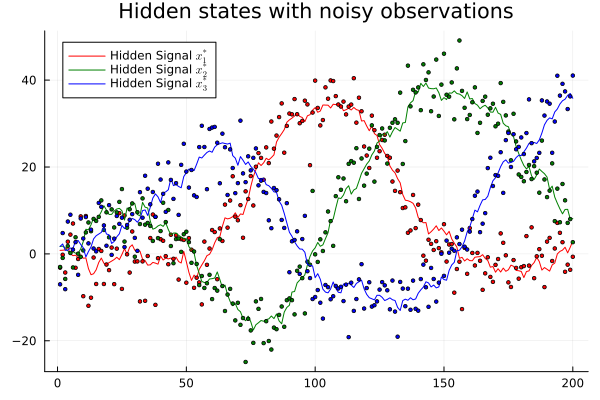

In [15]:
_p = plot(title="Hidden states with noisy observations")

_p = plot!(_p, getindex.(_xˣ_seq, 1), label="Hidden Signal " * L"x^*_1", color=:red)
_p = scatter!(_p, getindex.(_y_seq, 1), label=false, markersize=2, color=:red)

_p = plot!(_p, getindex.(_xˣ_seq, 2), label="Hidden Signal " * L"x^*_2", color=:green)
_p = scatter!(_p, getindex.(_y_seq, 2), label=false, markersize=2, color=:green)

_p = plot!(_p, getindex.(_xˣ_seq, 3), label="Hidden Signal " * L"x^*_3", color=:blue)
_p = scatter!(_p, getindex.(_y_seq, 3), label=false, markersize=2, color=:blue)

plot(_p)

## The Generative Model
We now use `RxInfer`:

In [19]:
@model function rotate_ssm(_y_seq, _x₀, _A, _C, _Q, _R)
    _x_prior ~ MvNormalMeanCovariance(mean(_x₀), cov(_x₀))
    _xₜ₋₁ = _x_prior
    for t in 1:length(_y_seq)
        _x_seq[t] ~ MvNormalMeanCovariance(_A*_xₜ₋₁, _Q) ## `s` is a sequence of hidden states
        ##- s[t] ~ MvNormalMeanCovariance(f(B= B, sₜ₋₁= sₜ₋₁), Q) ## `s` is a sequence of hidden states
        _y_seq[t] ~ MvNormalMeanCovariance(_C*_x_seq[t], _R) ## `y` is a sequence of "clamped" observations
        _xₜ₋₁ = _x_seq[t]
    end
end

Specify a prior for the initial hidden state:

In [20]:
_xˣ₀ = MvNormalMeanCovariance(zeros(3), 10.0*diageye(3));

Perform inference:

In [23]:
## We assume the _B̃, _Ã, _Q̃, _R̃ are known, i.e. not hidden, even though the tildes
## in their names indicate that they are hidden 
result = infer(
    model=       rotate_ssm(_x₀=_xˣ₀, _A=_Aˣ, _C=_Cˣ, _Q=_Qˣ, _R=_Rˣ),
    data=        (_y_seq = _y_seq,),
    free_energy= true
);

Extract the results:

In [24]:
result.posteriors

Dict{Symbol, Any} with 2 entries:
  :_x_seq   => MvNormalWeightedMeanPrecision{Float64, Vector{Float64}, Matrix{F…
  :_x_prior => MvNormalWeightedMeanPrecision(…

In [25]:
xmarginals  = result.posteriors[:_x_seq];

Visualize:

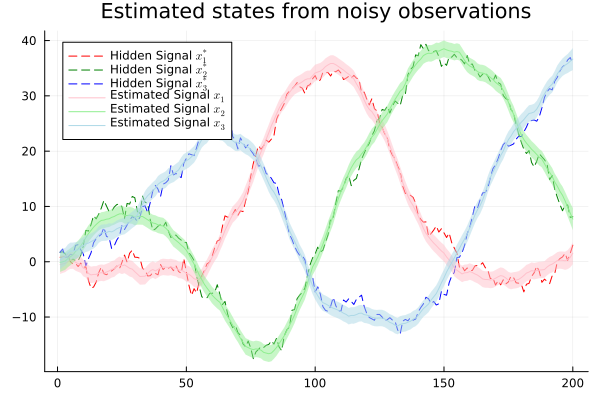

In [28]:
_p = plot(title="Estimated states from noisy observations")
_p = plot!(_p, getindex.(_xˣ_seq, 1), label="Hidden Signal " * L"x^*_1", color=:red, linestyle=:dash)
_p = plot!(_p, getindex.(_xˣ_seq, 2), label="Hidden Signal " * L"x^*_2", color=:green, linestyle=:dash)
_p = plot!(_p, getindex.(_xˣ_seq, 3), label="Hidden Signal " * L"x^*_3", color=:blue, linestyle=:dash)

_p = plot!(_p, getindex.(mean.(xmarginals), 1), ribbon=getindex.(var.(xmarginals), 1) .|> sqrt, fillalpha=0.5, label="Estimated Signal " * L"x_1", color=:pink)
_p = plot!(_p, getindex.(mean.(xmarginals), 2), ribbon=getindex.(var.(xmarginals), 2) .|> sqrt, fillalpha=0.5, label="Estimated Signal " * L"x_2", color=:lightgreen)
_p = plot!(_p, getindex.(mean.(xmarginals), 3), ribbon=getindex.(var.(xmarginals), 3) .|> sqrt, fillalpha=0.5, label="Estimated Signal " * L"x_3", color=:lightblue)
plot(_p)

As we can see from our plot, estimated signal resembles closely to the real hidden states with small variance. We maybe also interested in the value for minus log evidence:

In [29]:
## given the analytical solution, the free energy will be equal to the negative log evidence
logevidence = -result.free_energy; 
logevidence

1-element Vector{Float64}:
 -1814.862291590095